In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df=pd.read_csv('Iris.csv')
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [4]:
df['Species'] = df['Species'].astype('category').cat.codes
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


In [5]:
df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2
149,150,5.9,3.0,5.1,1.8,2


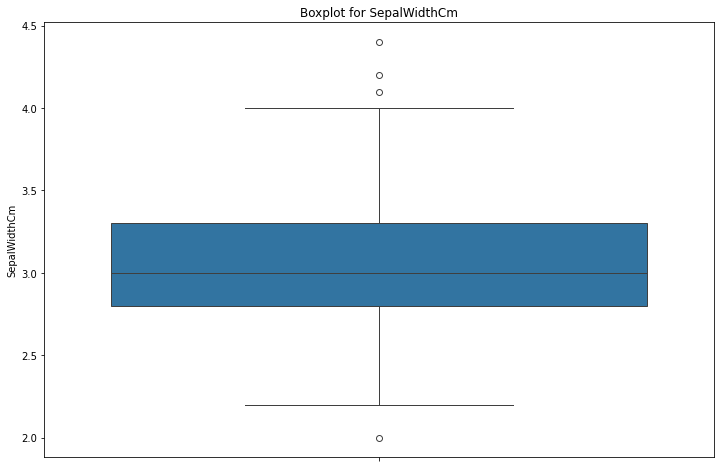

In [6]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df['SepalWidthCm'])
plt.title("Boxplot for SepalWidthCm")
plt.show()

In [7]:
Q1=df['SepalWidthCm'].quantile(0.25)
Q3=df['SepalWidthCm'].quantile(0.75)
IQR=Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['SepalWidthCm']=df['SepalWidthCm'].clip(lower=lower_bound, upper=upper_bound)

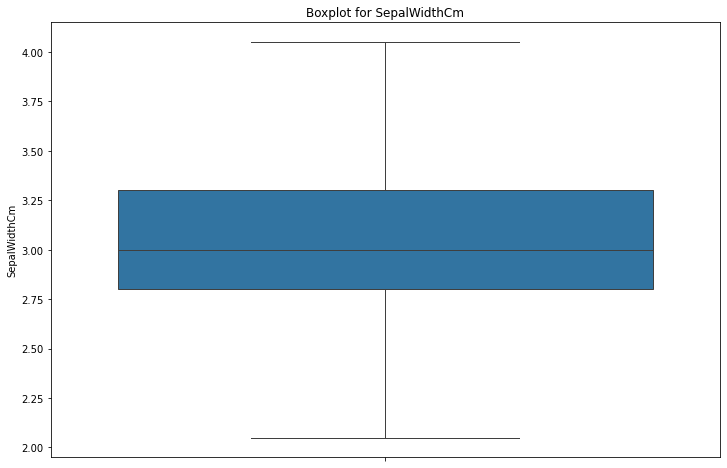

In [8]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df['SepalWidthCm'])
plt.title("Boxplot for SepalWidthCm")
plt.show()

In [9]:
X = df.drop("Species", axis=1)
y = df["Species"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [11]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### With sklearn

In [12]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[13,  0,  0],
       [ 0, 16,  0],
       [ 0,  0,  9]])

In [15]:
TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (TP + FP + FN)

accuracy = np.sum(TP) / np.sum(cm)
error_rate = 1 - accuracy
precision = np.mean(TP / (TP + FP))
recall = np.mean(TP / (TP + FN))
f1_score = 2 * ((precision * recall) / (precision + recall))

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


#### Feature	            Class 0 (Setosa)	Class 1 (Versicolor)	Class 2 (Virginica)
#### Sepal Length    	μ=5.0, σ=0.35	     μ=5.9, σ=0.5	              μ=6.5, σ=0.6
#### Sepal Width    	 μ=3.4, σ=0.3	       μ=2.8, σ=0.3	                μ=3.0, σ=0.3
#### Petal Length    	 μ=1.5, σ=0.2	       μ=4.2, σ=0.4	                μ=5.5, σ=0.5
#### Petal Width	      μ=0.2, σ=0.1	        μ=1.3, σ=0.2	             μ=2.0, σ=0.3

### Without sklearn

In [16]:
def separate_by_class(X, y):
    separated = {}
    for i in range(len(y)):
        label = y.iloc[i]
        if label not in separated:
            separated[label] = []
        separated[label].append(X[i])
    return separated

In [17]:
def summarize_dataset(X):
    summaries = [(np.mean(feature), np.std(feature)) for feature in zip(*X)]
    return summaries

In [18]:
def summarize_by_class(X, y):
    separated = separate_by_class(X, y)
    summaries = {}
    for class_value, rows in separated.items():
        summaries[class_value] = summarize_dataset(rows)
    return summaries

summaries = summarize_by_class(X_train, y_train)

In [19]:
def gaussian_probability(x, mean, std):
    pi = 3.1416
    exponent = np.exp(-((x - mean) ** 2 / (2 * std ** 2)))
    return (1 / (np.sqrt(2 * pi) * std)) * exponent

In [20]:
def calculate_class_probabilities(summaries, row):
    probabilities = {}
    
    for class_value, class_summaries in summaries.items():
        probabilities[class_value] = 1
        
        for i in range(len(class_summaries)):
            mean, std = class_summaries[i]
            x = row[i]
            probabilities[class_value] *= gaussian_probability(x, mean, std)
    
    return probabilities

In [21]:
def predict(summaries, row):
    probabilities = calculate_class_probabilities(summaries, row)
    return max(probabilities, key=probabilities.get)

In [22]:
def get_predictions(summaries, X_test):
    predictions = []
    for row in X_test:
        predictions.append(predict(summaries, row))
    return predictions

y_pred_manual = get_predictions(summaries, X_test)

In [23]:
y_test_np = y_test.to_numpy()
y_pred_np = np.array(y_pred_manual)

classes = np.unique(y_test_np)
cm_manual = np.zeros((len(classes), len(classes)), dtype=int)

for i in range(len(y_test_np)):
    cm_manual[y_test_np[i]][y_pred_np[i]] += 1

print("Confusion Matrix:\n", cm_manual)

Confusion Matrix:
 [[13  0  0]
 [ 0 16  0]
 [ 0  0  9]]


In [24]:
TP = np.diag(cm_manual)
FP = np.sum(cm_manual, axis=0) - TP
FN = np.sum(cm_manual, axis=1) - TP
TN = np.sum(cm_manual) - (TP + FP + FN)

accuracy = np.sum(TP) / np.sum(cm_manual)
error_rate = 1 - accuracy
precision = np.mean(TP / (TP + FP))
recall = np.mean(TP / (TP + FN))
f1_score = 2 * ((precision * recall) / (precision + recall))

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
